In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 📥 Loading the Dataset

In this step, we load the dataset into a Pandas DataFrame using `read_csv()`.  
This allows us to work with structured tabular data easily.

In [6]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🔍 Initial Data Exploration

- `df.head()` → Displays the first 5 rows of the dataset.
- `df.shape` → Shows the number of rows and columns.
- `df.info()` → Provides information about data types and non-null values.
- `df.describe()` → Gives statistical summary (mean, std, min, max, etc.) for numerical columns.

This step helps us understand the structure and basic properties of the dataset.

In [7]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### ⚠️ Checking Missing Values and Target Variable Distribution

- `df.isnull().sum()` → Checks for missing values in each column.
- `df['Churn'].value_counts()` → Counts occurrences of each class in the target variable.

This helps identify data imbalance and missing data issues.

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### 📊 Visualizing Target Variable

- `sns.countplot(x='Churn', data=df)` → Creates a count plot of churn values.
- `plt.show()` → Displays the plot.

This visualization helps us understand the distribution of customers who stayed vs churned.

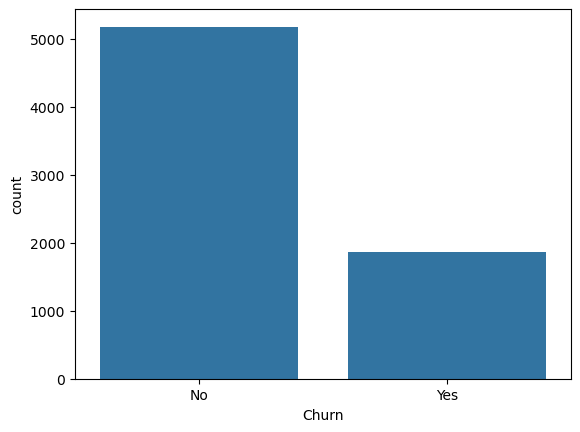

In [10]:
sns.countplot(x='Churn', data=df)
plt.show()

### 🔄 Converting Data Types

- `df['TotalCharges'].dtype` → Checks current data type.
- `pd.to_numeric(..., errors='coerce')` → Converts column to numeric.
- Invalid values are converted to `NaN`.

This ensures the column is usable for numerical analysis.

In [11]:
df['TotalCharges'].dtype



dtype('O')

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### 🧹 Handling Missing Values

- `df['TotalCharges'].isnull().sum()` → Checks missing values after conversion.
- `df.dropna()` → Removes rows with missing values.

This step ensures clean data before model building.

In [13]:
df['TotalCharges'].isnull().sum()

11

In [14]:
df = df.dropna()
df.shape

(7032, 21)

### ❌ Removing Irrelevant Features

- `df.drop('customerID', axis=1)` → Removes customer ID column.

This column is not useful for prediction and may negatively affect the model.

In [15]:
df = df.drop('customerID', axis=1)

### 🔢 Encoding Target Variable

- `df['Churn'].map({'Yes': 1, 'No': 0})` → Converts categorical values into numerical format.

Machine learning models require numerical input, so encoding is necessary.

In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### 🎯 Splitting Features and Target

- `X = df.drop('Churn', axis=1)` → Feature variables
- `y = df['Churn']` → Target variable

This separates input data from the output label.

In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']


### 📐 Checking Data Dimensions

- `X.shape` → Shape of feature dataset
- `y.shape` → Shape of target variable
- `y.isnull().sum()` → Ensures no missing values in target

This step verifies that the dataset is ready for training.

In [18]:
print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [19]:
y.isnull().sum()

0

### 🚀 Splitting Data into Training and Testing Sets

- `train_test_split()` splits the dataset into training and testing sets.
- `test_size=0.2` → 20% data for testing, 80% for training.
- `random_state=42` → Ensures reproducibility.

This marks the beginning of the machine learning pipeline.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)